In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Sales_Analysis.csv')
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [4]:
df.isna().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isna().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(618)

In [8]:
df.drop_duplicates(inplace=True)

In [10]:
df['Order ID'].duplicated().sum()

np.int64(7249)

In [16]:
df['Order ID'].duplicated().sum()

np.int64(7249)

In [28]:
df.drop_duplicates('Order ID',keep='first',inplace=True)

In [29]:
df['Order ID'].duplicated().sum()

np.int64(0)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178438 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          178438 non-null  object
 1   Product           178438 non-null  object
 2   Quantity Ordered  178438 non-null  object
 3   Price Each        178438 non-null  object
 4   Order Date        178438 non-null  object
 5   Purchase Address  178438 non-null  object
dtypes: object(6)
memory usage: 9.5+ MB


In [31]:
df.rename(columns={'Quantity Ordered': "Quantity",'Price Each':'Price', 'Order Date':"Date", 'Purchase Address':'Address'}, inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178438 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Order ID  178438 non-null  object
 1   Product   178438 non-null  object
 2   Quantity  178438 non-null  object
 3   Price     178438 non-null  object
 4   Date      178438 non-null  object
 5   Address   178438 non-null  object
dtypes: object(6)
memory usage: 9.5+ MB


In [33]:
df.drop(df[df['Order ID']=='Order ID'].index, inplace=True)
df.head()

,Order ID,Product,Quantity,Price,Date,Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
6,176562,USB-C Charging Cable,1,11.95,04/29/19 13:03,"381 Wilson St, San Francisco, CA 94016"


In [34]:
df['Order ID'] = pd.to_numeric(df['Order ID'])
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Price'] = pd.to_numeric(df['Price'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y %H:%M')

In [35]:
df.head()

,Order ID,Product,Quantity,Price,Date,Address
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001"
6,176562,USB-C Charging Cable,1,11.95,2019-04-29 13:03:00,"381 Wilson St, San Francisco, CA 94016"


In [36]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [37]:
address_df = df['Address'].str.split(",", n=3, expand=True)
address_df.columns = ['Street', 'City', 'ZIP']

for cols in address_df.columns:
    address_df[cols] = address_df[cols].str.strip()

address_df.head()

,Street,City,ZIP
0,917 1st St,Dallas,TX 75001
2,682 Chestnut St,Boston,MA 02215
3,669 Spruce St,Los Angeles,CA 90001
5,333 8th St,Los Angeles,CA 90001
6,381 Wilson St,San Francisco,CA 94016


In [38]:
df=pd.concat([df,address_df], axis=1)

In [39]:
df.to_csv('clean_sales_file.csv', index=False)

Now clean file has been created and now we can use clean file to perform EDA

In [16]:
# Importing necessary modules first

import pandas as pd
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
%matplotlib inline

In [18]:
# Reading clean dataframe

df = pd.read_csv('clean_sales_file.csv')
df.head()

,Order ID,Product,Quantity,Price,Date,Address,Month,Year,Street,City,ZIP
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,2019,917 1st St,Dallas,TX 75001
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,2019,682 Chestnut St,Boston,MA 02215
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,2019,669 Spruce St,Los Angeles,CA 90001
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,2019,669 Spruce St,Los Angeles,CA 90001
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,2019,333 8th St,Los Angeles,CA 90001


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185686 entries, 0 to 185685
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Order ID  185686 non-null  int64  
 1   Product   185686 non-null  object 
 2   Quantity  185686 non-null  int64  
 3   Price     185686 non-null  float64
 4   Date      185686 non-null  object 
 5   Address   185686 non-null  object 
 6   Month     185686 non-null  int64  
 7   Year      185686 non-null  int64  
 8   Street    185686 non-null  object 
 9   City      185686 non-null  object 
 10  ZIP       185686 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 15.6+ MB


In [20]:
df['Date']=pd.to_datetime(df['Date'], format="%Y-%m-%d %H:%M:%S")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185686 entries, 0 to 185685
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Order ID  185686 non-null  int64         
 1   Product   185686 non-null  object        
 2   Quantity  185686 non-null  int64         
 3   Price     185686 non-null  float64       
 4   Date      185686 non-null  datetime64[ns]
 5   Address   185686 non-null  object        
 6   Month     185686 non-null  int64         
 7   Year      185686 non-null  int64         
 8   Street    185686 non-null  object        
 9   City      185686 non-null  object        
 10  ZIP       185686 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 15.6+ MB


In [22]:
df.drop(['Address','Street'], axis=1, inplace=True)

In [23]:
df.head()

,Order ID,Product,Quantity,Price,Date,Month,Year,City,ZIP
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,4,2019,Dallas,TX 75001
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,4,2019,Boston,MA 02215
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,4,2019,Los Angeles,CA 90001
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,4,2019,Los Angeles,CA 90001
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,4,2019,Los Angeles,CA 90001


In [62]:
df['Product'].value_counts()

Product
USB-C Charging Cable          21855
Lightning Charging Cable      21605
AAA Batteries (4-pack)        20609
AA Batteries (4-pack)         20558
Wired Headphones              18848
Apple Airpods Headphones      15521
Bose SoundSport Headphones    13295
27in FHD Monitor               7495
iPhone                         6838
27in 4K Gaming Monitor         6224
34in Ultrawide Monitor         6174
Google Phone                   5521
Flatscreen TV                  4793
Macbook Pro Laptop             4720
ThinkPad Laptop                4124
20in Monitor                   4096
Vareebadd Phone                2064
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

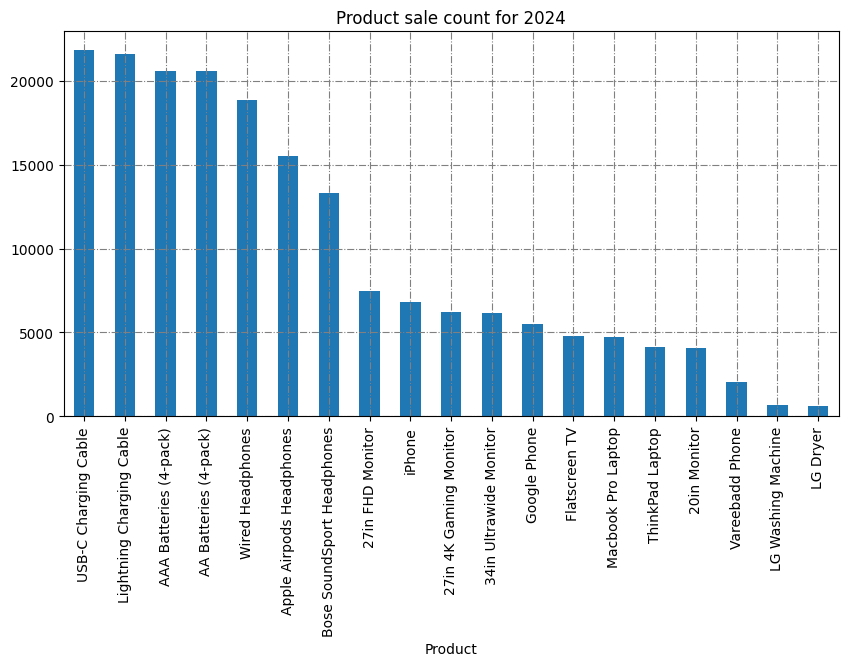

In [103]:
df['Product'].value_counts().plot(kind='bar', figsize=(10,5), title='Product sale count for 2024')
plt.grid(1,'both',color='gray', linestyle = "-.")
plt.show()

In [25]:
df['Year'].value_counts()

Year
2019    185652
2020        34
Name: count, dtype: int64

In [26]:
df.drop(index=df.loc[df['Year']==2020].index, axis=0, inplace=True)

In [27]:
# Since there is only one year then we do not need to have it since we know its value
df.drop('Year', axis=1, inplace=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185652 entries, 0 to 185685
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Order ID  185652 non-null  int64         
 1   Product   185652 non-null  object        
 2   Quantity  185652 non-null  int64         
 3   Price     185652 non-null  float64       
 4   Date      185652 non-null  datetime64[ns]
 5   Month     185652 non-null  int64         
 6   City      185652 non-null  object        
 7   ZIP       185652 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 12.7+ MB


In [29]:
df['Month'].value_counts().sort_index()

Month
1      9665
2     11957
3     15128
4     18257
5     16552
6     13535
7     14275
8     11943
9     11603
10    20249
11    17544
12    24944
Name: count, dtype: int64

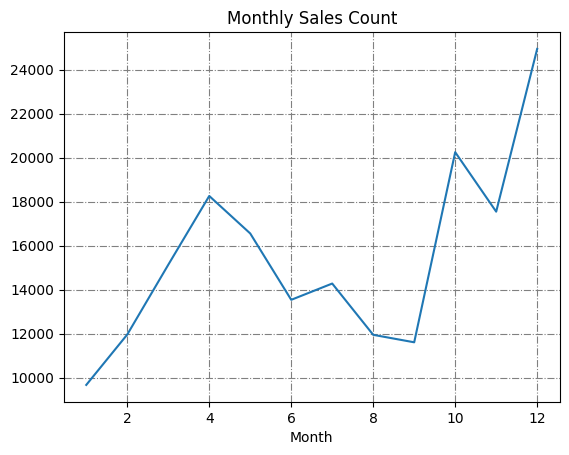

In [96]:
df['Month'].value_counts().sort_index().plot(kind='line', title='Monthly Sales Count')
plt.grid(1,'both',color='gray', linestyle = "-.")
plt.show()

In [63]:
df['City'].value_counts()

City
San Francisco    44650
Los Angeles      29563
New York City    24837
Boston           19897
Atlanta          14863
Dallas           14795
Seattle          14712
Portland         12447
Austin            9888
Name: count, dtype: int64

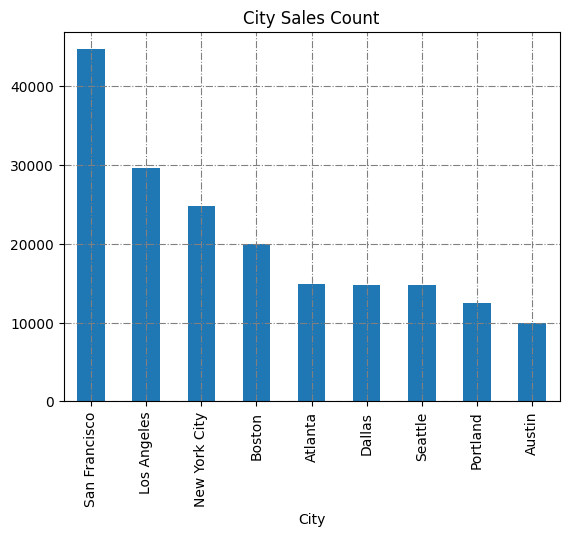

In [97]:
df["City"].value_counts().plot(kind='bar', title='City Sales Count')
plt.grid(1,'both',color='gray', linestyle = "-.")
plt.show()